# Lab06 - Classification using KNN
Name = Mahamad Arsh Vahora
Date = 4/27/26


In [1]:
%matplotlib inline
import random
import pandas as pd
import matplotlib.pyplot as plt
plt.rc('figure', figsize=(5, 4))

In [2]:
from sklearn.datasets import load_digits
digits = load_digits()
#print(digits.DESCR)

In [3]:
# Show the data part
digits.data.shape

(1797, 64)

In [4]:
#First image
digits.data[0]

array([ 0.,  0.,  5., 13.,  9.,  1.,  0.,  0.,  0.,  0., 13., 15., 10.,
       15.,  5.,  0.,  0.,  3., 15.,  2.,  0., 11.,  8.,  0.,  0.,  4.,
       12.,  0.,  0.,  8.,  8.,  0.,  0.,  5.,  8.,  0.,  0.,  9.,  8.,
        0.,  0.,  4., 11.,  0.,  1., 12.,  7.,  0.,  0.,  2., 14.,  5.,
       10., 12.,  0.,  0.,  0.,  0.,  6., 13., 10.,  0.,  0.,  0.])

In [5]:
digits.target.shape

(1797,)

In [6]:
digits.target[0]

0

In [7]:
digits.images[1]

array([[ 0.,  0.,  0., 12., 13.,  5.,  0.,  0.],
       [ 0.,  0.,  0., 11., 16.,  9.,  0.,  0.],
       [ 0.,  0.,  3., 15., 16.,  6.,  0.,  0.],
       [ 0.,  7., 15., 16., 16.,  2.,  0.,  0.],
       [ 0.,  0.,  1., 16., 16.,  3.,  0.,  0.],
       [ 0.,  0.,  1., 16., 16.,  6.,  0.,  0.],
       [ 0.,  0.,  1., 16., 16.,  6.,  0.,  0.],
       [ 0.,  0.,  0., 11., 16., 10.,  0.,  0.]])

In [8]:
digits.target[1]

1

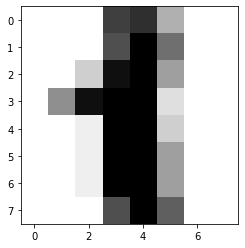

In [9]:
# 
import matplotlib.pyplot as plt
axes = plt.subplot()
image = plt.imshow(digits.images[1], cmap = plt.cm.gray_r)


In [10]:
#Secon image
digits.data[1]

array([ 0.,  0.,  0., 12., 13.,  5.,  0.,  0.,  0.,  0.,  0., 11., 16.,
        9.,  0.,  0.,  0.,  0.,  3., 15., 16.,  6.,  0.,  0.,  0.,  7.,
       15., 16., 16.,  2.,  0.,  0.,  0.,  0.,  1., 16., 16.,  3.,  0.,
        0.,  0.,  0.,  1., 16., 16.,  6.,  0.,  0.,  0.,  0.,  1., 16.,
       16.,  6.,  0.,  0.,  0.,  0.,  0., 11., 16., 10.,  0.,  0.])

In [11]:
# Three record
#digits.data[0:3]

In [12]:
# Three target
digits.target[0:3]

array([0, 1, 2])

In [13]:
df = digits.target
len(df)
df

array([0, 1, 2, ..., 8, 9, 8])

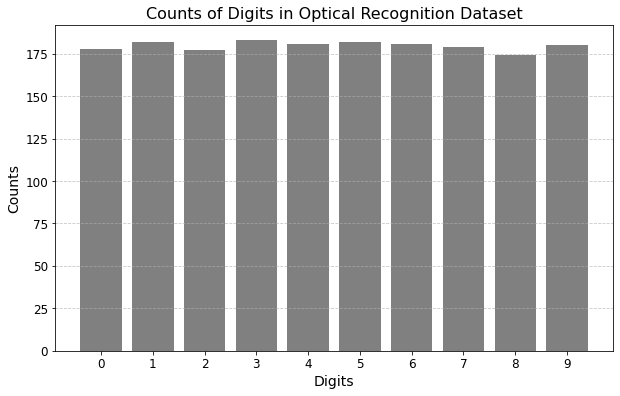

In [14]:
import matplotlib.pyplot as plt
from sklearn.datasets import load_digits
import numpy as np

# Load the digits dataset
digits = load_digits()

# Get the target labels
targets = digits.target

# Count the occurrences of each digit
unique, counts = np.unique(targets, return_counts=True)

# Plot the bar chart
plt.figure(figsize=(10, 6))
plt.bar(unique, counts, color='grey')
plt.xticks(unique, fontsize=12)
plt.yticks(fontsize=12)
plt.xlabel('Digits', fontsize=14)
plt.ylabel('Counts', fontsize=14)
plt.title('Counts of Digits in Optical Recognition Dataset', fontsize=16)
plt.grid(axis='y', linestyle='--', alpha=0.7)

# Show the chart
plt.show()


In [15]:
# Step 2  Splitting the data from training and testing

from sklearn.model_selection import train_test_split

X_train,X_test, y_train, y_test = train_test_split(digits.data, digits.target, random_state = 11, test_size =0.2)

In [16]:
# In your exam, you need show the output
print(X_train.shape)
print(X_test.shape)
print(y_train.shape)
print(y_test.shape)


(1437, 64)
(360, 64)
(1437,)
(360,)


In [17]:
# Step 3 Creating the Model

from sklearn.neighbors import KNeighborsClassifier

knn = KNeighborsClassifier()

knn.fit(X = X_train, y = y_train)


KNeighborsClassifier()

In [18]:
# Step 4 Prediciting
predicted = knn.predict(X = X_test)
predicted[0:20]

array([0, 4, 9, 9, 3, 1, 4, 1, 5, 0, 4, 9, 4, 1, 5, 3, 3, 8, 5, 6])

In [19]:
# Compare the results
expected = y_test
expected[0:20]


array([0, 4, 9, 9, 3, 1, 4, 1, 5, 0, 4, 9, 4, 1, 5, 3, 3, 8, 3, 6])

In [20]:
print(predicted[:30])
print(expected[:30])

[0 4 9 9 3 1 4 1 5 0 4 9 4 1 5 3 3 8 5 6 9 6 0 6 9 3 2 1 8 1]
[0 4 9 9 3 1 4 1 5 0 4 9 4 1 5 3 3 8 3 6 9 6 0 6 9 3 2 1 8 1]


In [21]:
wrong = []
for p, e in zip (predicted, expected ):
    if p != e:
        wrong.append((p,e))

print(wrong)

[(5, 3), (8, 9), (4, 9), (7, 3), (7, 4)]


# LAB 07 Classification Evaluation

#Name - Mahamad Arsh Vahora

#Date - 4/29/26

In [22]:
# Caculate and display accurage
accuracy = (len(predicted) - len(wrong))/len(predicted)
print(accuracy)
print(format(accuracy, '.2%'))
print(f'{accuracy:.2%}')

0.9861111111111112
98.61%
98.61%


In [23]:
# Evaluate the results
accuracy = knn.score( X_test,y_test)
print(accuracy)

0.9861111111111112


In [24]:
# Confusion Matrix

from sklearn.metrics import confusion_matrix

matrix = confusion_matrix(y_true = expected, y_pred = predicted)
print(matrix)



[[38  0  0  0  0  0  0  0  0  0]
 [ 0 37  0  0  0  0  0  0  0  0]
 [ 0  0 39  0  0  0  0  0  0  0]
 [ 0  0  0 39  0  1  0  1  0  0]
 [ 0  0  0  0 40  0  0  1  0  0]
 [ 0  0  0  0  0 27  0  0  0  0]
 [ 0  0  0  0  0  0 30  0  0  0]
 [ 0  0  0  0  0  0  0 36  0  0]
 [ 0  0  0  0  0  0  0  0 34  0]
 [ 0  0  0  0  1  0  0  0  1 35]]


In [26]:
from sklearn.metrics import classification_report

report = classification_report(expected, predicted)

print(report)


              precision    recall  f1-score   support

           0       1.00      1.00      1.00        38
           1       1.00      1.00      1.00        37
           2       1.00      1.00      1.00        39
           3       1.00      0.95      0.97        41
           4       0.98      0.98      0.98        41
           5       0.96      1.00      0.98        27
           6       1.00      1.00      1.00        30
           7       0.95      1.00      0.97        36
           8       0.97      1.00      0.99        34
           9       1.00      0.95      0.97        37

    accuracy                           0.99       360
   macro avg       0.99      0.99      0.99       360
weighted avg       0.99      0.99      0.99       360



<AxesSubplot:>

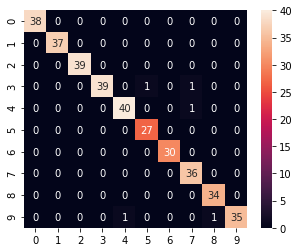

In [27]:
import pandas as pd
matrix_df = pd.DataFrame(matrix)
import seaborn as sns
sns.heatmap(matrix_df, annot = True)